<h3>Práctica 3: Sensado y análisis inercial</h3>
Diana Jaramillo<br>


In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np
from scipy.signal import butter, filtfilt, medfilt
from scipy.signal import find_peaks
from scipy.fft import fft, fftfreq
import joblib

In [20]:
dir="E:\Cicese\Sensores\data_inercial"
dir_test="E:\Cicese\Sensores\data_inercial\\test"
dir_tiros="E:\Cicese\Sensores\data_inercial\Tiros\Tiros_Intentos_Practica_3.csv"
datatiros=pd.read_csv(dir_tiros)

alldata=pd.DataFrame()
for i in os.listdir(dir):
    if i.endswith(".csv"):
        data=pd.read_csv(os.path.join(dir,i))
        data['Persona']=i.split("_")[0]
        data['itento']=i.split("_")[1]
        data['Result']=datatiros[datatiros['Nombre Archivo']==i]['clase_Tiro'].values[0]
        alldata=pd.concat([alldata,data],ignore_index=True)
alldata.columns = alldata.columns.str.strip()  # Eliminar espacios en los nombres de las columnas
alldata.head()  

,SensorId,TimeStamp (s),FrameNumber,AccX (g),AccY (g),AccZ (g),GyroX (deg/s),GyroY (deg/s),GyroZ (deg/s),MagX (uT),...,LinAccX (g),LinAccY (g),LinAccZ (g),Pressure (kPa),Altitude (m),Temperature (degC),HeaveMotion (m),Persona,itento,Result
0,5,0.00,0,0.711285,0.445489,-0.438775,-4.186089,-25.954462,37.283886,-11.897106,...,-0.251966,0.225923,-0.162264,0.0,0.0,0.0,0.0,Edgar,01.csv,0
1,5,0.01,1,0.716007,0.412368,-0.476258,1.774544,-33.612278,43.597775,-11.107863,...,-0.264523,0.265432,-0.179785,0.0,0.0,0.0,0.0,Edgar,01.csv,0
2,5,0.02,2,0.638184,0.426291,-0.477852,10.980103,-41.389175,52.426315,-11.107863,...,-0.176743,0.242873,-0.206875,0.0,0.0,0.0,0.0,Edgar,01.csv,0
3,5,0.03,3,0.556013,0.431206,-0.517698,20.320208,-45.200264,62.977596,-10.377083,...,-0.066843,0.226866,-0.229977,0.0,0.0,0.0,0.0,Edgar,01.csv,0
4,5,0.04,4,0.515587,0.421873,-0.555837,30.499054,-47.926231,72.878075,-9.675533,...,-0.025297,0.256047,-0.250635,0.0,0.0,0.0,0.0,Edgar,01.csv,0


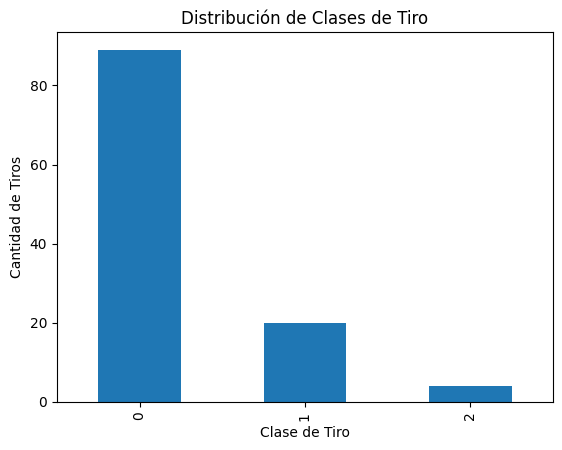

In [21]:
datatiros['clase_Tiro'].value_counts().plot(kind='bar')
plt.xlabel('Clase de Tiro')
plt.ylabel('Cantidad de Tiros')
plt.title('Distribución de Clases de Tiro')
plt.show()

Como los tiros de clase 2 son que tambien encestaron se volveran a 1

In [22]:
alldata['Result'].replace({2:1},inplace=True)
print(alldata['Result'].unique())

[0 1]


Ver el nombre de las columnas para ver con que datos se trabajan

In [23]:
print(alldata.columns.tolist())

['SensorId', 'TimeStamp (s)', 'FrameNumber', 'AccX (g)', 'AccY (g)', 'AccZ (g)', 'GyroX (deg/s)', 'GyroY (deg/s)', 'GyroZ (deg/s)', 'MagX (uT)', 'MagY (uT)', 'MagZ (uT)', 'EulerX (deg)', 'EulerY (deg)', 'EulerZ (deg)', 'QuatW', 'QuatX', 'QuatY', 'QuatZ', 'LinAccX (g)', 'LinAccY (g)', 'LinAccZ (g)', 'Pressure (kPa)', 'Altitude (m)', 'Temperature (degC)', 'HeaveMotion (m)', 'Persona', 'itento', 'Result']


Plot de los sensores como acelerometro y gyroscopio para ver como esta la señal sin procesamiento.

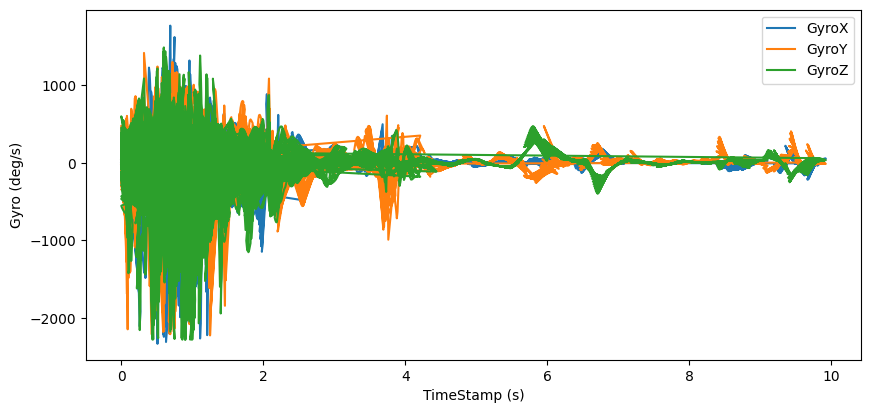

In [24]:
#plot de gyroscopio
plt.figure(figsize=(10, 10))
plt.subplot(2, 1, 1)
plt.plot(alldata['TimeStamp (s)'], alldata['GyroX (deg/s)'], label='GyroX')
plt.plot(alldata['TimeStamp (s)'], alldata['GyroY (deg/s)'], label='GyroY')
plt.plot(alldata['TimeStamp (s)'], alldata['GyroZ (deg/s)'], label='GyroZ')
plt.xlabel('TimeStamp (s)')
plt.ylabel('Gyro (deg/s)')
plt.legend()

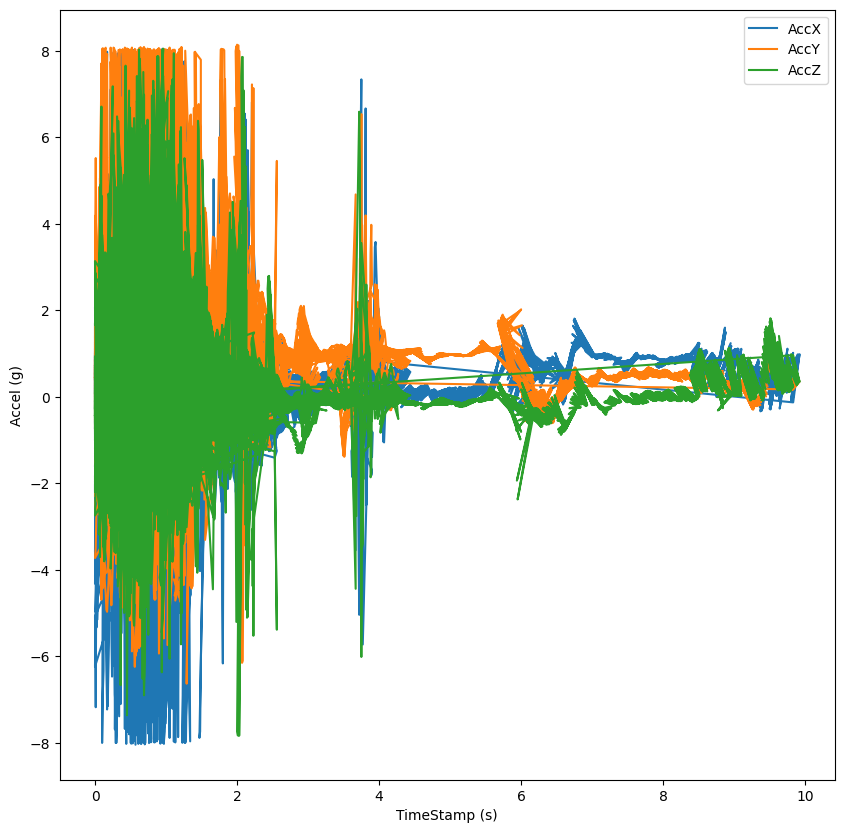

In [25]:
#plot de acelerometro
plt.figure(figsize=(10, 10))
plt.plot(alldata['TimeStamp (s)'], alldata['AccX (g)'], label='AccX')
plt.plot(alldata['TimeStamp (s)'], alldata['AccY (g)'], label='AccY')
plt.plot(alldata['TimeStamp (s)'], alldata['AccZ (g)'], label='AccZ')
plt.xlabel('TimeStamp (s)')
plt.ylabel('Accel (g)')
plt.legend()

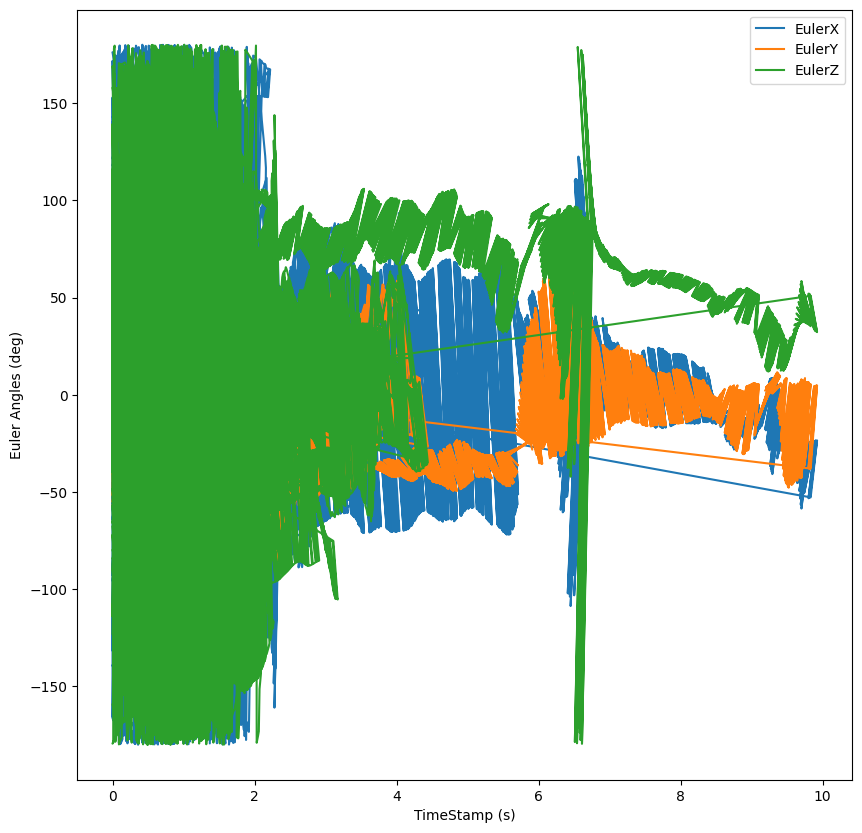

In [26]:
#plot euler angles
plt.figure(figsize=(10, 10))
plt.plot(alldata['TimeStamp (s)'], alldata['EulerX (deg)'], label='EulerX')
plt.plot(alldata['TimeStamp (s)'], alldata['EulerY (deg)'], label='EulerY')
plt.plot(alldata['TimeStamp (s)'], alldata['EulerZ (deg)'], label='EulerZ')
plt.xlabel('TimeStamp (s)')
plt.ylabel('Euler Angles (deg)')
plt.legend()

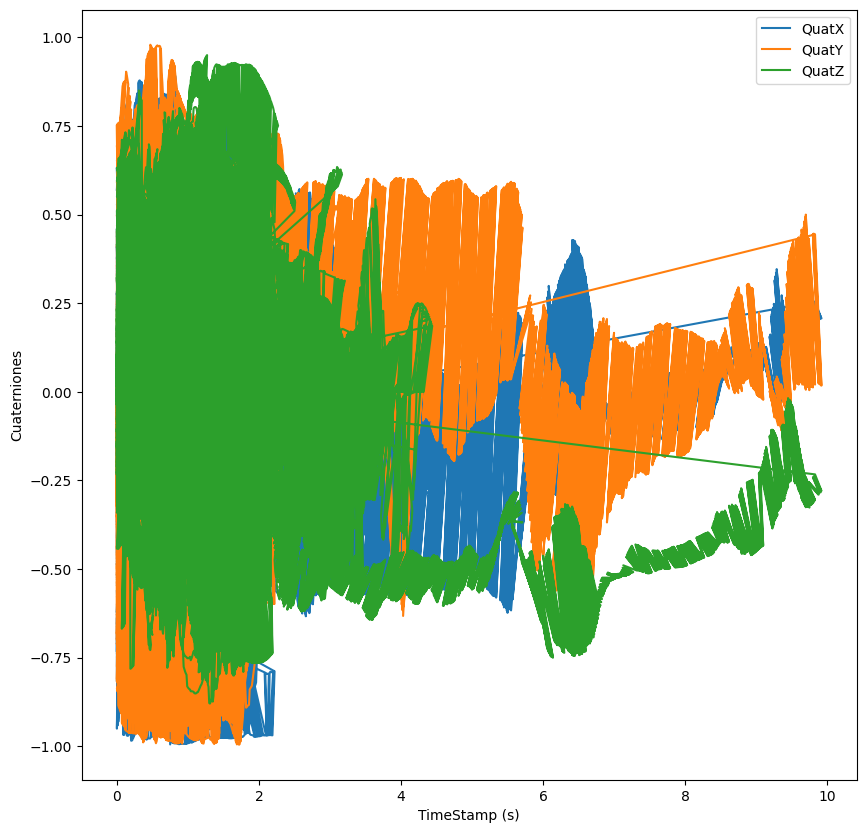

In [27]:
#plot cuaternion
plt.figure(figsize=(10, 10))
plt.plot(alldata['TimeStamp (s)'], alldata['QuatX'], label='QuatX')
plt.plot(alldata['TimeStamp (s)'], alldata['QuatY'], label='QuatY')
plt.plot(alldata['TimeStamp (s)'], alldata['QuatZ'], label='QuatZ')
plt.xlabel('TimeStamp (s)')
plt.ylabel('Cuaterniones')
plt.legend()

Definicion de los filtros a utilizar

In [ ]:
def _safe_filtfilt(b, a, x):
    #Filtro que evita errores de filtfilt en secuencias muy cortas
    min_len = 3 * max(len(a), len(b))
    if len(x) <= min_len:
        return x
    return filtfilt(b, a, x)

def butter_lowpass_zero_phase(x, fs, cutoff=10.0, order=4):
    #filtro para eliminar ruido de alta frecuencia en las señales de aceleración y giroscopio
    nyq = 0.5 * fs
    wn = cutoff / nyq
    b, a = butter(order, wn, btype="low")
    return _safe_filtfilt(b, a, x)

def butter_lowpass_zero_phase_gravity(x, fs, cutoff=0.3, order=2):
    #filtro para eliminar la componente de gravedad en las señales de aceleración, limpiando la señal para obtener solo la aceleración dinámica
    nyq = 0.5 * fs
    wn = cutoff / nyq
    b, a = butter(order, wn, btype="low")
    return _safe_filtfilt(b, a, x)

In [ ]:
alldata_filt = alldata.copy()
sensor_cols = [c for c in alldata.columns if any(k in c for k in ["Acc", "Gyro", "Euler"])]

# Aplicar filtrado por grupo de Persona e intento para preservar las características específicas de cada intento, evitando mezclar datos de diferentes intentos o personas que podrían tener patrones de movimiento distintos.
for (_, _), g in alldata.groupby(["Persona", "itento"], sort=False):
    idx = g.index
    t = pd.to_numeric(g["TimeStamp (s)"], errors="coerce").values
    if np.sum(np.isfinite(t)) < 5:
        continue

    dt = np.diff(t[np.isfinite(t)])
    dt = dt[dt > 0]
    if len(dt) == 0:
        continue
    fs = 1.0 / np.median(dt)
    if not np.isfinite(fs) or fs <= 0:
        continue

    nyq = 0.5 * fs
    cutoff_lp = min(10.0, nyq * 0.95)   
    cutoff_grav = min(0.3, nyq * 0.95) 

    for c in sensor_cols:
        x = pd.to_numeric(g[c], errors="coerce").interpolate(limit_direction="both").values

        #Filtro de mediana para eliminar picos espurios
        k = 5 if len(x) >= 5 else 3
        if k % 2 == 0:
            k += 1
        x_med = medfilt(x, kernel_size=k)

        # filtro de Butterworth para eliminar ruido de alta frecuencia en las señales de aceleración y giroscopio
        x_f = butter_lowpass_zero_phase(x_med, fs=fs, cutoff=cutoff_lp, order=4)
        alldata_filt.loc[idx, c + "_f"] = x_f

    # Separar componente de gravedad y dinámica en aceleración
    for c in ["AccX (g)", "AccY (g)", "AccZ (g)"]:
        if c in g.columns:
            x = alldata_filt.loc[idx, c + "_f"].values
            g_comp = butter_lowpass_zero_phase_gravity(x, fs=fs, cutoff=cutoff_grav, order=2)
            alldata_filt.loc[idx, c + "_grav"] = g_comp
            alldata_filt.loc[idx, c + "_dyn"] = x - g_comp

print("Datos filtrados:")
print([c for c in alldata_filt.columns if c.endswith("_f")][:10], "...")


Done. Filtered dataframe: alldata_filt
['AccX (g)_f', 'AccY (g)_f', 'AccZ (g)_f', 'GyroX (deg/s)_f', 'GyroY (deg/s)_f', 'GyroZ (deg/s)_f', 'EulerX (deg)_f', 'EulerY (deg)_f', 'EulerZ (deg)_f', 'LinAccX (g)_f'] ...


Ejemplo de como se ven las señales ya pasadas por el proceso de filtrado en cada intento de tiro.

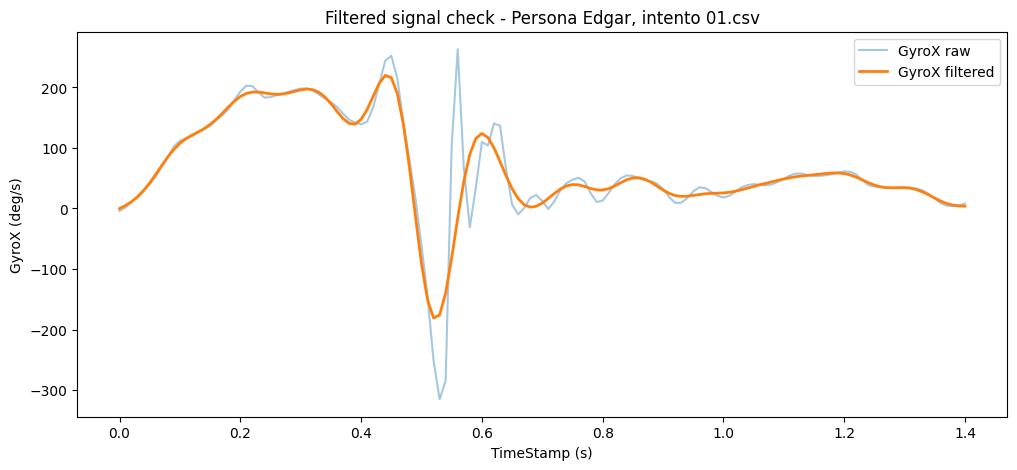

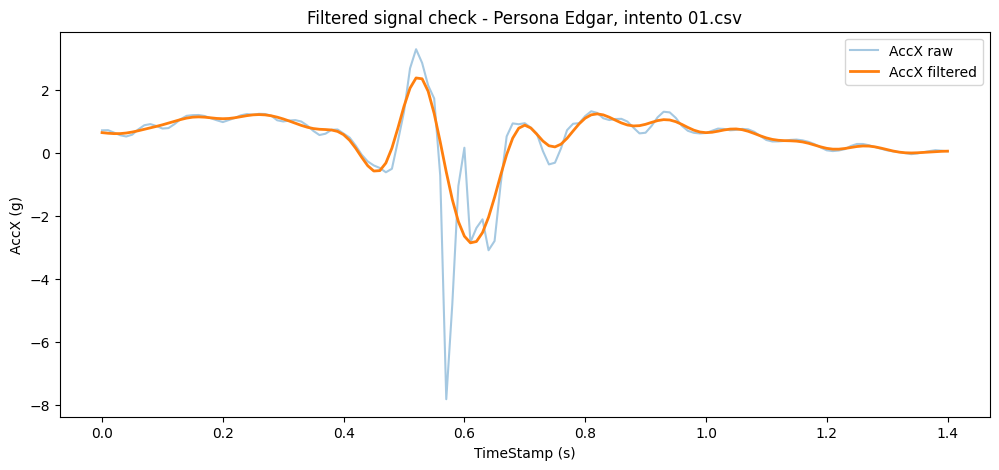

In [49]:
#Se puede revisar cada intento cambiendo el indice en iloc
p0, i0 = alldata_filt[["Persona", "itento"]].iloc[0]
g0 = alldata_filt[(alldata_filt["Persona"] == p0) & (alldata_filt["itento"] == i0)]

plt.figure(figsize=(12, 5))
plt.plot(g0["TimeStamp (s)"], g0["GyroX (deg/s)"], alpha=0.4, label="GyroX raw")
plt.plot(g0["TimeStamp (s)"], g0["GyroX (deg/s)_f"], linewidth=2, label="GyroX filtered")
plt.xlabel("TimeStamp (s)")
plt.ylabel("GyroX (deg/s)")
plt.title(f"Filtered signal check - Persona {p0}, intento {i0}")
plt.legend()
plt.show()
plt.figure(figsize=(12, 5))
plt.plot(g0["TimeStamp (s)"], g0["AccX (g)"], alpha=0.4, label="AccX raw")
plt.plot(g0["TimeStamp (s)"], g0["AccX (g)_f"], linewidth=2, label="AccX filtered")
plt.xlabel("TimeStamp (s)")
plt.ylabel("AccX (g)")
plt.title(f"Filtered signal check - Persona {p0}, intento {i0}")
plt.legend()
plt.show()

Separacion de los segmentos de cuando se realiza el tiro y cuando no, para facilitar el análisis posterior de las características de cada segmento. Esto es importante porque los patrones de movimiento pueden ser muy diferentes durante el tiro en comparación con los momentos de preparación o descanso, y separar estos segmentos permite un análisis más preciso de las características específicas del tiro.

Successfully extracted 111 shot segments.


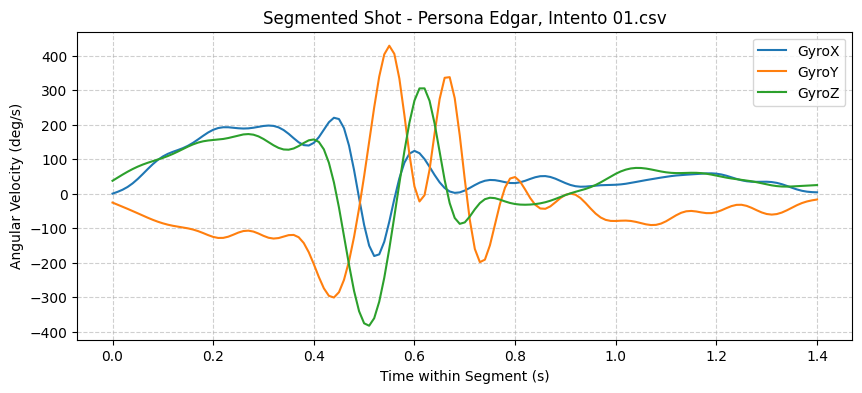

In [ ]:
shot_segments = []
S_ANTES = 1.0  #Ventana de tiempo entre los picos de tiro
S_DESPUES = 1.0  
#Agrupar por persona e intento para tener claro que componente corresponte al segmento del tiro, evitando mezclar datos de diferentes intentos o personas que podrían tener patrones de movimiento distintos. 
for (persona, intento), trial_df in alldata_filt.groupby(["Persona", "itento"], sort=False):
    if trial_df.shape[0] < 10:
        continue

    #Calcular la magnitud de la señal de giroscopio filtrada para detectar el pico del tiro, ya que el tiro suele estar asociado con un movimiento brusco que se refleja como un pico en la magnitud del giroscopio.
    gyro_mag = trial_df[["GyroX (deg/s)_f", "GyroY (deg/s)_f", "GyroZ (deg/s)_f"]].pow(2).sum(axis=1).pow(0.5)

    #Encontrar picos 
    peaks, _ = find_peaks(gyro_mag, height=gyro_mag.quantile(0.9), distance=int(len(gyro_mag)/2))
    if len(peaks) == 0:
        #Maximo en caso de que no
        peak_idx = gyro_mag.idxmax()
    else:
        #Elegir el pico mas relevante
        peak_idx = peaks[np.argmax(gyro_mag.iloc[peaks])]
        peak_idx = trial_df.index[peak_idx] 

    peak_time = trial_df.loc[peak_idx, "TimeStamp (s)"]

    #Definir los tiempos del momento del tiro
    start_time = peak_time - S_ANTES
    end_time = peak_time + S_DESPUES

    #Segmentacion
    segment = trial_df[(trial_df["TimeStamp (s)"] >= start_time) & (trial_df["TimeStamp (s)"] <= end_time)].copy()
    
    #Normalizacion del tiempo
    segment["SegmentTime (s)"] = segment["TimeStamp (s)"] - segment["TimeStamp (s)"].iloc[0]
    
    shot_segments.append(segment)

print(f"Successfully extracted {len(shot_segments)} shot segments.")

#Visualizacion de datos
if shot_segments:
    sample_segment = shot_segments[0]
    p = sample_segment['Persona'].iloc[0]
    i = sample_segment['itento'].iloc[0]
    
    plt.figure(figsize=(10, 4))
    plt.plot(sample_segment["SegmentTime (s)"], sample_segment["GyroX (deg/s)_f"], label="GyroX")
    plt.plot(sample_segment["SegmentTime (s)"], sample_segment["GyroY (deg/s)_f"], label="GyroY")
    plt.plot(sample_segment["SegmentTime (s)"], sample_segment["GyroZ (deg/s)_f"], label="GyroZ")
    plt.title(f"Segmented Shot - Persona {p}, Intento {i}")
    plt.xlabel("Time within Segment (s)")
    plt.ylabel("Angular Velocity (deg/s)")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.show()

Extraccion de caracteristicas de los segmentos para entrenar a los modelos

In [50]:
from scipy.stats import skew, kurtosis
#Kurtosis y skewness para medir la asimetría y la forma de la distribución de las señales, lo que puede ayudar a capturar características distintivas de los tiros exitosos vs fallidos.
features_list = []

#Definir las columnas
feature_cols = [c for c in alldata_filt.columns if c.endswith(('_f', '_dyn'))]

for segment_df in shot_segments:
    if segment_df.empty:
        continue
    
    features = {}
    # Identificador de la característica
    features['Persona'] = segment_df['Persona'].iloc[0]
    features['itento'] = segment_df['itento'].iloc[0]
    features['Result'] = segment_df['Result'].iloc[0]
    
    #Calcular la frecuencia de muestreo a partir del tiempo segmentado para las características espectrales
    time_vals = segment_df["SegmentTime (s)"].values
    if len(time_vals) > 1:
        fs = 1.0 / np.mean(np.diff(time_vals))
    else:
        fs = 1.0 

    for col in feature_cols:
        signal = segment_df[col].values
        
        #Features estadisticas
        features[f'{col}_mean'] = np.mean(signal)
        features[f'{col}_std'] = np.std(signal)
        features[f'{col}_max'] = np.max(signal)
        features[f'{col}_min'] = np.min(signal)
        features[f'{col}_rms'] = np.sqrt(np.mean(signal**2))
        features[f'{col}_skew'] = skew(signal)
        features[f'{col}_kurtosis'] = kurtosis(signal)
        
        #Features temporales
        features[f'{col}_zcr'] = np.sum(np.diff(np.sign(signal)) != 0) / (2 * len(signal))
        features[f'{col}_energy'] = np.sum(signal**2)

        #Features espectrales
        N = len(signal)
        if N > 1 and fs > 0:
            yf = fft(signal)
            xf = fftfreq(N, 1 / fs)
            
            #Parte positiva del espectro
            yf_half = 2.0/N * np.abs(yf[0:N//2])
            xf_half = xf[0:N//2]

            # Evitar división por cero si el espectro es todo ceros
            if np.sum(yf_half) > 0:
                features[f'{col}_spectral_centroid'] = np.sum(xf_half * yf_half) / np.sum(yf_half)
            else:
                features[f'{col}_spectral_centroid'] = 0

            #Frecuencia dominante
            if len(yf_half) > 0:
                dominant_freq_idx = np.argmax(yf_half)
                features[f'{col}_dominant_freq'] = xf_half[dominant_freq_idx]
                features[f'{col}_spectral_power'] = yf_half[dominant_freq_idx]**2
            else:
                features[f'{col}_dominant_freq'] = 0
                features[f'{col}_spectral_power'] = 0
        else:
            features[f'{col}_spectral_centroid'] = 0
            features[f'{col}_dominant_freq'] = 0
            features[f'{col}_spectral_power'] = 0

    features_list.append(features)

#Dataframe final
features_df = pd.DataFrame(features_list)

print(f"Dataframe final: {features_df.shape}")
features_df.head()

Dataframe final: (111, 183)


,Persona,itento,Result,AccX (g)_f_mean,AccX (g)_f_std,AccX (g)_f_max,AccX (g)_f_min,AccX (g)_f_rms,AccX (g)_f_skew,AccX (g)_f_kurtosis,...,AccZ (g)_dyn_max,AccZ (g)_dyn_min,AccZ (g)_dyn_rms,AccZ (g)_dyn_skew,AccZ (g)_dyn_kurtosis,AccZ (g)_dyn_zcr,AccZ (g)_dyn_energy,AccZ (g)_dyn_spectral_centroid,AccZ (g)_dyn_dominant_freq,AccZ (g)_dyn_spectral_power
0,Edgar,01.csv,0,0.481786,0.852453,2.374936,-2.863028,0.979180,-1.820308,4.973908,...,1.951563,-1.749352,0.660135,-0.101795,1.226704,0.014184,61.444695,5.679496,0.709220,0.221369
1,Edgar,02.csv,0,0.450605,0.547479,1.532394,-0.555130,0.709068,0.758759,-0.718868,...,0.231142,-0.529966,0.219558,-1.379771,0.439474,0.016260,5.929304,3.070733,0.813008,0.053594
2,Edgar,03.csv,0,0.080124,0.516481,0.916324,-1.869995,0.522659,-1.851060,4.156481,...,0.154132,-2.125847,1.004321,-0.301988,-1.011045,0.009434,106.917996,2.749950,0.000000,2.585684
3,Edgar,04.csv,0,0.427702,0.882903,2.379461,-3.173916,0.981043,-1.623682,4.578653,...,2.642670,-1.854331,0.820891,0.590133,1.685470,0.010714,94.340733,5.918513,1.428571,0.593521
4,Edgar,05.csv,0,0.339874,0.878973,1.483761,-2.971669,0.942395,-1.460927,2.295073,...,-0.026378,-1.886390,1.350179,0.307870,0.245345,0.000000,193.236364,4.441407,0.000000,6.766147


### Creacion de los modelos a utilizar
Se escogieron los modelos de regresion logistica, random forest y SVM por ser los mas comunes, tambien gradient boosting por ser un modelo de ensamble que suele tener buen desempeño en tareas de clasificación y gaussian naive bayes por ser un modelo probabilistico.

Logistic Regression: Mean F1-Score = 0.6858 (Std = 0.0555)
Random Forest: Mean F1-Score = 0.7151 (Std = 0.0582)
Gradient Boosting: Mean F1-Score = 0.7043 (Std = 0.0357)
SVM: Mean F1-Score = 0.7014 (Std = 0.0289)
Gaussian Naive Bayes: Mean F1-Score = 0.5751 (Std = 0.0538)

--- Best Model: Random Forest ---

Classification Report (on test set):
              precision    recall  f1-score   support

           0       0.79      0.96      0.87        27
           1       0.00      0.00      0.00         7

    accuracy                           0.76        34
   macro avg       0.39      0.48      0.43        34
weighted avg       0.63      0.76      0.69        34

Confusion Matrix:


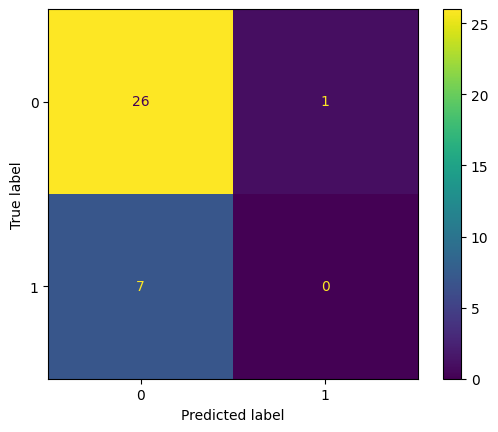

In [ ]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import warnings

warnings.filterwarnings('ignore')

#Separar datos y etiquetas
X = features_df.drop(columns=['Persona', 'itento', 'Result'])
y = features_df['Result']

# Manejar valores infinitos y faltantes
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.fillna(X.median(), inplace=True)

# Definir los modelos a utilizar
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "Gaussian Naive Bayes": GaussianNB()
}

#Validacion cruzaadad e modelos
results = {}
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    #Crear pipeline para estandarizar características y entrenar el modelo
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', model)
    ])
    
    
    cv_scores = cross_val_score(pipeline, X, y, cv=skf, scoring='f1_weighted')
    results[name] = cv_scores
    print(f"{name}: Mean F1-Score = {cv_scores.mean():.4f} (Std = {cv_scores.std():.4f})")

#Mejor modelo basado en el F1-Score promedio
best_model_name = max(results, key=lambda name: results[name].mean())
print(f"\n--- Best Model: {best_model_name} ---")

#Dividir los datos en entrenamiento y prueba para evaluar el mejor modelo con un conjunto de test propio
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

#Entrenar el mejor modelo en el conjunto de entrenamiento y evaluar en el conjunto de prueba
best_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', models[best_model_name])
])
best_pipeline.fit(X_train, y_train)
y_pred = best_pipeline.predict(X_test)

#Matriz de confusion y reporte de clasificacion
print("\nClassification Report (on test set):")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot()
plt.show()

### **Paso 5: Validación Externa**
Utilizar un pipeline para probar el modelo con los datos proporcionados para test

In [ ]:

# 5.1 Exportar el mejor modelo
# El objeto 'best_pipeline' contiene tanto el escalador de datos como el clasificador.
model_filename = 'best_basketball_shot_model.joblib'
joblib.dump(best_pipeline, model_filename)

print(f"Modelo '{best_model_name}' guardado como '{model_filename}'")

#Funcion para procesar los nuevos datos crudos de igual manera que los datos de entrenamiento
def process_raw_data(df):
    """Aplica el filtrado y la separación de componentes a un DataFrame de datos crudos."""
    df_filt = df.copy()
    sensor_cols = [c for c in df.columns if any(k in c for k in ["Acc", "Gyro", "Euler"])]
    
    t = pd.to_numeric(df["TimeStamp (s)"], errors="coerce").values
    fs = 1.0 / np.median(np.diff(t[np.isfinite(t)]))

    for c in sensor_cols:
        x = pd.to_numeric(df[c], errors="coerce").interpolate(limit_direction="both").values
        k = 5 if len(x) >= 5 else 3
        if k % 2 == 0: k += 1
        x_med = medfilt(x, kernel_size=k)
        x_f = butter_lowpass_zero_phase(x_med, fs=fs, cutoff=min(10.0, 0.5*fs*0.95))
        df_filt[c + "_f"] = x_f

    for c in ["AccX (g)", "AccY (g)", "AccZ (g)"]:
        if c in df.columns:
            x = df_filt[c + "_f"].values
            g_comp = butter_lowpass_zero_phase_gravity(x, fs=fs, cutoff=min(0.3, 0.5*fs*0.95))
            df_filt[c + "_grav"] = g_comp
            df_filt[c + "_dyn"] = x - g_comp
            
    return df_filt
#Funcion para segmentar el tiro
def segment_shot(df_processed):
    gyro_mag = df_processed[["GyroX (deg/s)_f", "GyroY (deg/s)_f", "GyroZ (deg/s)_f"]].pow(2).sum(axis=1).pow(0.5)
    peaks, _ = find_peaks(gyro_mag, height=gyro_mag.quantile(0.9), distance=int(len(gyro_mag)/2))
    
    if len(peaks) == 0:
        peak_idx = gyro_mag.idxmax()
    else:
        peak_idx = peaks[np.argmax(gyro_mag.iloc[peaks])]
        peak_idx = df_processed.index[peak_idx]

    peak_time = df_processed.loc[peak_idx, "TimeStamp (s)"]
    segment = df_processed[(df_processed["TimeStamp (s)"] >= peak_time - 1.0) & (df_processed["TimeStamp (s)"] <= peak_time + 1.0)].copy()
    segment["SegmentTime (s)"] = segment["TimeStamp (s)"] - segment["TimeStamp (s)"].iloc[0]
    return segment

#Funcion para extraer las caracteristicas
def extract_features_from_segment(segment_df):
    features = {}
    feature_cols = [c for c in segment_df.columns if c.endswith(('_f', '_dyn'))]
    
    time_vals = segment_df["SegmentTime (s)"].values
    fs = 1.0 / np.mean(np.diff(time_vals)) if len(time_vals) > 1 else 1.0

    for col in feature_cols:
        signal = segment_df[col].values
        features[f'{col}_mean'] = np.mean(signal)
        features[f'{col}_std'] = np.std(signal)
        features[f'{col}_max'] = np.max(signal)
        features[f'{col}_min'] = np.min(signal)
        features[f'{col}_rms'] = np.sqrt(np.mean(signal**2))
        features[f'{col}_skew'] = skew(signal)
        features[f'{col}_kurtosis'] = kurtosis(signal)
        features[f'{col}_zcr'] = np.sum(np.diff(np.sign(signal)) != 0) / (2 * len(signal))
        features[f'{col}_energy'] = np.sum(signal**2)
        
        N = len(signal)
        if N > 1 and fs > 0:
            yf, xf = fft(signal), fftfreq(N, 1 / fs)
            yf_half, xf_half = 2.0/N * np.abs(yf[0:N//2]), xf[0:N//2]
            if np.sum(yf_half) > 0:
                features[f'{col}_spectral_centroid'] = np.sum(xf_half * yf_half) / np.sum(yf_half)
            else:
                features[f'{col}_spectral_centroid'] = 0
            if len(yf_half) > 0:
                idx = np.argmax(yf_half)
                features[f'{col}_dominant_freq'] = xf_half[idx]
                features[f'{col}_spectral_power'] = yf_half[idx]**2
            else:
                features[f'{col}_dominant_freq'], features[f'{col}_spectral_power'] = 0, 0
        else:
            features[f'{col}_spectral_centroid'], features[f'{col}_dominant_freq'], features[f'{col}_spectral_power'] = 0, 0, 0
            
    return features


#Funcion para poder realziar la prediccion de los datos
def predict_shot_from_file(filepath, model):
    raw_df = pd.read_csv(filepath)
    raw_df.columns = raw_df.columns.str.strip()
    processed_df = process_raw_data(raw_df)
    shot_segment = segment_shot(processed_df)
    features = extract_features_from_segment(shot_segment)
    features_df = pd.DataFrame([features])
    training_cols = model.steps[0][1].feature_names_in_
    features_df = features_df.reindex(columns=training_cols, fill_value=0)
    prediction = model.predict(features_df)[0]
    prediction_proba = model.predict_proba(features_df)[0]
    
    return "Éxito" if prediction == 1 else "Fallo", prediction_proba

# --- Prueba del pipeline ---
# Cargar el modelo guardado
loaded_model = joblib.load(model_filename)

# Listar archivos en el directorio de prueba
test_files = [f for f in os.listdir(dir_test) if f.endswith('.csv')]
if test_files:
    for f in test_files:
        test_file_path = os.path.join(dir_test, f)
    
        print(f"\nEjecutando inferencia en el archivo: {f}")
        
        # Realizar la predicción
        resultado, probabilidades = predict_shot_from_file(test_file_path, loaded_model)
    
        print(f"Resultado de la predicción: {resultado}")
        print(f"Probabilidades -> Fallo (0): {probabilidades[0]:.2%}, Éxito (1): {probabilidades[1]:.2%}")
else:
    print(f"No se encontraron archivos CSV en el directorio de prueba: {dir_test}")


Modelo 'Random Forest' guardado como 'best_basketball_shot_model.joblib'

Ejecutando inferencia en el archivo: Joan_01.csv
Resultado de la predicción: Fallo
Probabilidades -> Fallo (0): 70.00%, Éxito (1): 30.00%

Ejecutando inferencia en el archivo: Joan_02.csv
Resultado de la predicción: Fallo
Probabilidades -> Fallo (0): 65.00%, Éxito (1): 35.00%

Ejecutando inferencia en el archivo: Joan_03.csv
Resultado de la predicción: Fallo
Probabilidades -> Fallo (0): 76.00%, Éxito (1): 24.00%

Ejecutando inferencia en el archivo: Joan_04.csv
Resultado de la predicción: Fallo
Probabilidades -> Fallo (0): 63.00%, Éxito (1): 37.00%

Ejecutando inferencia en el archivo: Joan_05.csv
Resultado de la predicción: Fallo
Probabilidades -> Fallo (0): 57.00%, Éxito (1): 43.00%

Ejecutando inferencia en el archivo: Joan_06.csv
Resultado de la predicción: Fallo
Probabilidades -> Fallo (0): 70.00%, Éxito (1): 30.00%

Ejecutando inferencia en el archivo: Joan_07.csv
Resultado de la predicción: Fallo
Probabili